In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dataset

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

training_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 32

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=100)

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


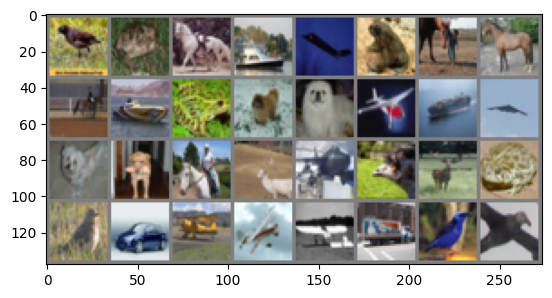

['bird', 'frog', 'horse', 'ship', 'plane', 'frog', 'horse', 'horse', 'horse', 'ship', 'frog', 'dog', 'dog', 'plane', 'ship', 'plane', 'dog', 'dog', 'horse', 'deer', 'plane', 'bird', 'deer', 'frog', 'bird', 'car', 'plane', 'plane', 'plane', 'truck', 'bird', 'bird']


In [3]:
# Plot some images

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5 # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_dataloader)
images, labels = dataiter.next()

imshow(torchvision.utils.make_grid(images))
print([classes[labels[j]] for j in range(batch_size)])

In [4]:
# Dataset shape

images.shape

torch.Size([32, 3, 32, 32])

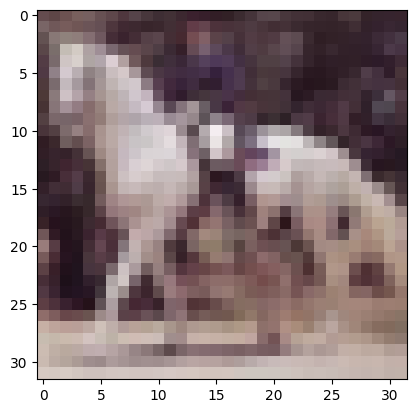

In [5]:
imshow(images[2])

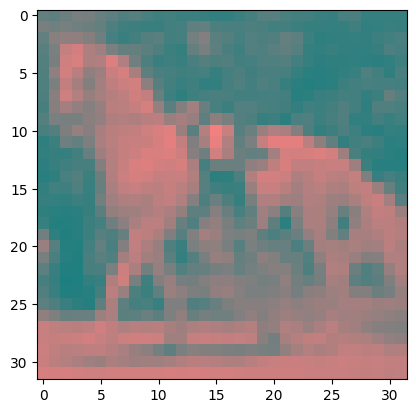

In [6]:
# Red channel

im_red = images[2].clone()
im_red[1:3,:,:] = 0.
imshow(im_red)

In [7]:
# Convolutional model

class NeuralNetwork(nn.Module):
    
    def __init__(self):

        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = NeuralNetwork()

In [8]:
# Training

model = NeuralNetwork()

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for i, data in enumerate(train_dataloader, 0):

        inputs, labels = data

        outputs = model(inputs) # Forward
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward() # Backward
        optimizer.step() # Gradient step

        running_loss += loss.item()
        print_every = 200
        if i % print_every == print_every - 1:
            print(f'epoch {epoch + 1} \t batch {i + 1} \t loss: {(running_loss/print_every):.3f}')
            running_loss = 0.0

print('Done!')

epoch 1 	 batch 200 	 loss: 2.304
epoch 1 	 batch 400 	 loss: 2.301
epoch 1 	 batch 600 	 loss: 2.298
epoch 1 	 batch 800 	 loss: 2.292
epoch 1 	 batch 1000 	 loss: 2.276
epoch 1 	 batch 1200 	 loss: 2.223
epoch 1 	 batch 1400 	 loss: 2.174
epoch 2 	 batch 200 	 loss: 2.061
epoch 2 	 batch 400 	 loss: 2.008
epoch 2 	 batch 600 	 loss: 1.981
epoch 2 	 batch 800 	 loss: 1.930
epoch 2 	 batch 1000 	 loss: 1.883
epoch 2 	 batch 1200 	 loss: 1.849
epoch 2 	 batch 1400 	 loss: 1.786
epoch 3 	 batch 200 	 loss: 1.741
epoch 3 	 batch 400 	 loss: 1.706
epoch 3 	 batch 600 	 loss: 1.687
epoch 3 	 batch 800 	 loss: 1.646
epoch 3 	 batch 1000 	 loss: 1.647
epoch 3 	 batch 1200 	 loss: 1.620
epoch 3 	 batch 1400 	 loss: 1.599
epoch 4 	 batch 200 	 loss: 1.564
epoch 4 	 batch 400 	 loss: 1.537
epoch 4 	 batch 600 	 loss: 1.527
epoch 4 	 batch 800 	 loss: 1.507
epoch 4 	 batch 1000 	 loss: 1.501
epoch 4 	 batch 1200 	 loss: 1.484
epoch 4 	 batch 1400 	 loss: 1.485
epoch 5 	 batch 200 	 loss: 1.468
ep

In [9]:
# Inference

correct = 0
total = 0

with torch.no_grad():

    for data in test_dataloader:

        images, labels = data

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test accuracy: {100 * correct / total}')

Test accuracy: 48.51


In [10]:
# Training with momentum

model = NeuralNetwork()

loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=.9)

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for i, data in enumerate(train_dataloader, 0):

        inputs, labels = data

        outputs = model(inputs) # Forward
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward() # Backward
        optimizer.step() # Gradient step

        running_loss += loss.item()
        print_every = 200
        if i % print_every == print_every - 1:
            print(f'epoch {epoch + 1} \t batch {i + 1} \t loss: {(running_loss/print_every):.3f}')
            running_loss = 0.0

print('Done!')

epoch 1 	 batch 200 	 loss: 2.261
epoch 1 	 batch 400 	 loss: 1.963
epoch 1 	 batch 600 	 loss: 1.736
epoch 1 	 batch 800 	 loss: 1.647
epoch 1 	 batch 1000 	 loss: 1.550
epoch 1 	 batch 1200 	 loss: 1.509
epoch 1 	 batch 1400 	 loss: 1.477
epoch 2 	 batch 200 	 loss: 1.393
epoch 2 	 batch 400 	 loss: 1.393
epoch 2 	 batch 600 	 loss: 1.355
epoch 2 	 batch 800 	 loss: 1.332
epoch 2 	 batch 1000 	 loss: 1.336
epoch 2 	 batch 1200 	 loss: 1.298
epoch 2 	 batch 1400 	 loss: 1.296
epoch 3 	 batch 200 	 loss: 1.245
epoch 3 	 batch 400 	 loss: 1.209
epoch 3 	 batch 600 	 loss: 1.206
epoch 3 	 batch 800 	 loss: 1.209
epoch 3 	 batch 1000 	 loss: 1.242
epoch 3 	 batch 1200 	 loss: 1.201
epoch 3 	 batch 1400 	 loss: 1.227
epoch 4 	 batch 200 	 loss: 1.118
epoch 4 	 batch 400 	 loss: 1.129
epoch 4 	 batch 600 	 loss: 1.136
epoch 4 	 batch 800 	 loss: 1.124
epoch 4 	 batch 1000 	 loss: 1.142
epoch 4 	 batch 1200 	 loss: 1.125
epoch 4 	 batch 1400 	 loss: 1.133
epoch 5 	 batch 200 	 loss: 1.064
ep

In [11]:
# Inference

correct = 0
total = 0

with torch.no_grad():

    for data in test_dataloader:

        images, labels = data

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test accuracy: {100 * correct / total}')

Test accuracy: 58.3


In [ ]:
from torchvision.models.feature_extraction import get_graph_node_names

nodes, _ = get_graph_node_names(model)
print(nodes)

['x', 'conv1', 'relu', 'pool', 'conv2', 'relu_1', 'pool_1', 'flatten', 'fc1', 'relu_2', 'fc2', 'relu_3', 'fc3']


In [ ]:
from torchvision.models.feature_extraction import create_feature_extractor

feature_extractor = create_feature_extractor(
	model, return_nodes=['conv1', 'relu', 'pool'])

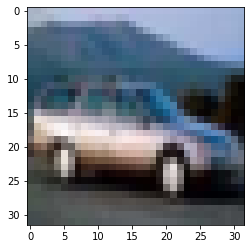

In [ ]:
dataloader = DataLoader(training_data, batch_size=batch_size)

dataiter = iter(dataloader)
images, labels = dataiter.next()

id = 4
imshow(images[id])

out = feature_extractor(images[id].unsqueeze(0))

conv1


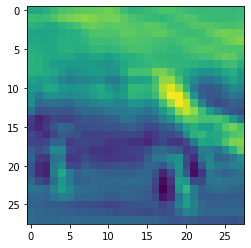

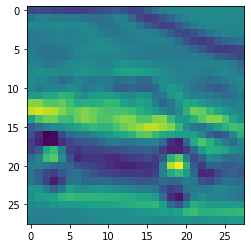

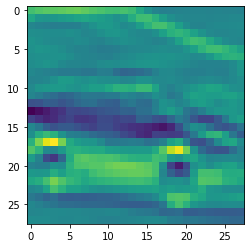

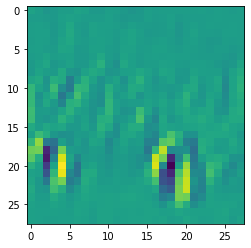

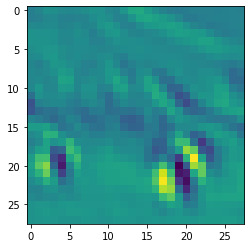

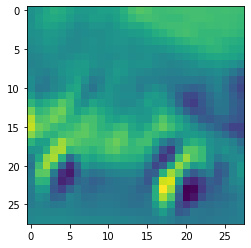

relu


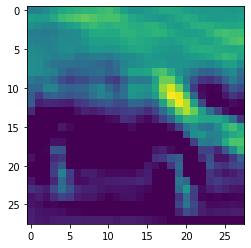

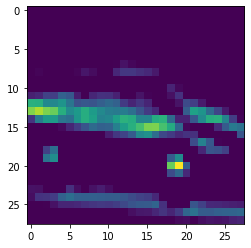

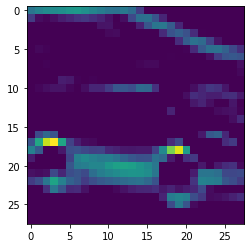

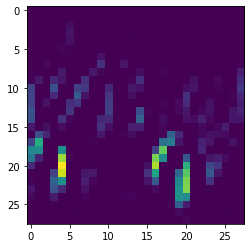

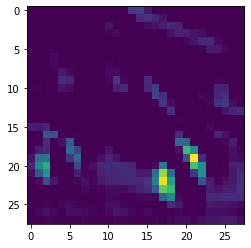

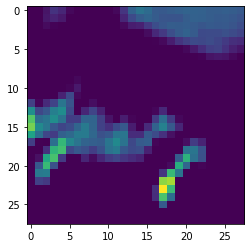

pool


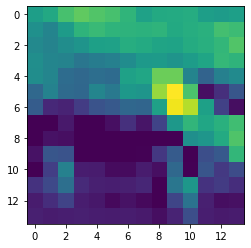

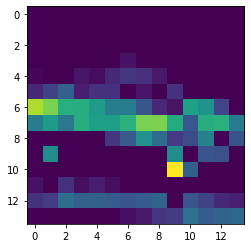

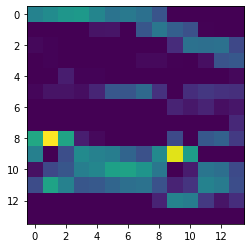

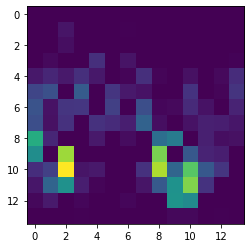

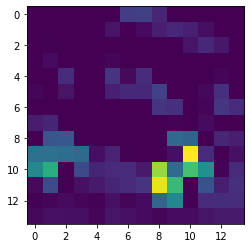

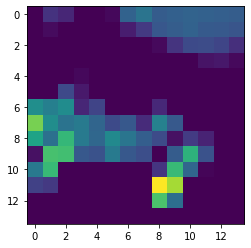

In [ ]:
print('conv1')
for i in range(6):
    plt.imshow(out['conv1'][0,i].detach())
    plt.show()

print('relu')
for i in range(6):
    plt.imshow(out['relu'][0,i].detach())
    plt.show()

print('pool')
for i in range(6):
    plt.imshow(out['pool'][0,i].detach())
    plt.show()

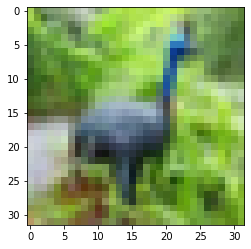

In [ ]:
id = 6
imshow(images[id])

out = feature_extractor(images[id].unsqueeze(0))

conv1


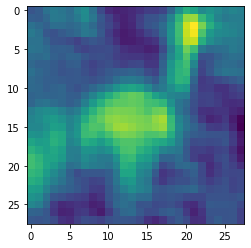

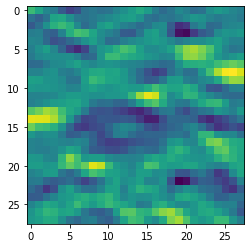

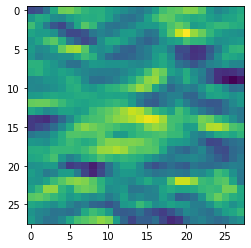

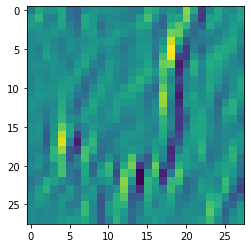

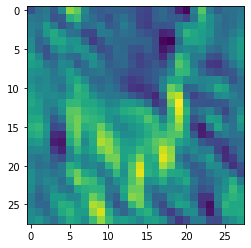

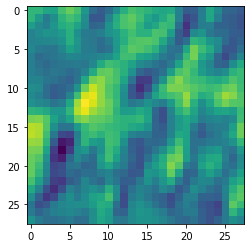

relu


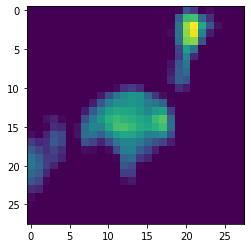

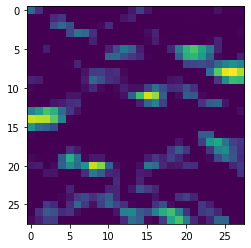

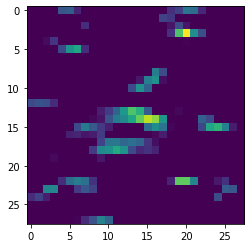

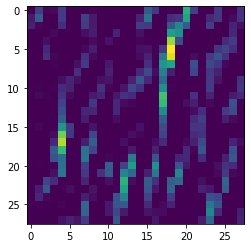

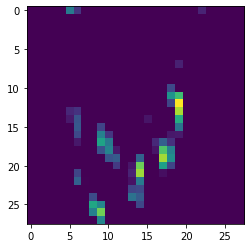

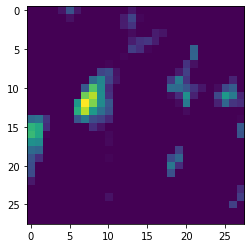

pool


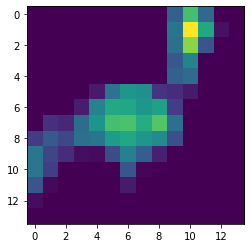

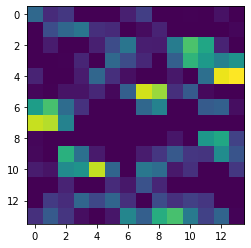

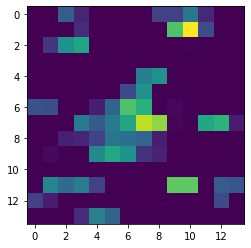

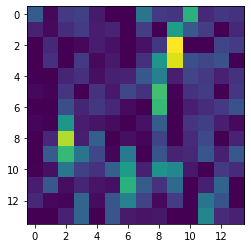

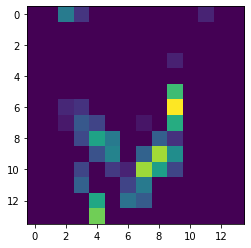

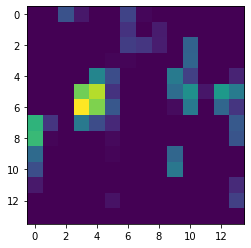

In [ ]:
print('conv1')
for i in range(6):
    plt.imshow(out['conv1'][0,i].detach())
    plt.show()

print('relu')
for i in range(6):
    plt.imshow(out['relu'][0,i].detach())
    plt.show()

print('pool')
for i in range(6):
    plt.imshow(out['pool'][0,i].detach())
    plt.show()